In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

data = data.dropna(
    subset=["TotalCharges"]
).copy()

data["ChurnFlag"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("Customer retention dataset loaded!")
print("Dataset shape:", data.shape)

display(
    data[
        [
            "customerID",
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "Churn",
            "ChurnFlag"
        ]
    ].head()
)

Customer retention dataset loaded!
Dataset shape: (7032, 22)


,customerID,tenure,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,7590-VHVEG,1,29.85,29.85,No,0
1,5575-GNVDE,34,56.95,1889.50,No,0
2,3668-QPYBK,2,53.85,108.15,Yes,1
3,7795-CFOCW,45,42.30,1840.75,No,0
4,9237-HQITU,2,70.70,151.65,Yes,1


In [3]:
total_customers = len(data)

churned_customers = data["ChurnFlag"].sum()

retained_customers = total_customers - churned_customers

churn_rate = (
    churned_customers / total_customers
) * 100

retention_rate = (
    retained_customers / total_customers
) * 100

average_tenure = data["tenure"].mean()

print("CUSTOMER RETENTION METRICS")
print("---------------------------")
print(f"Total Customers: {total_customers}")
print(f"Retained Customers: {retained_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Retention Rate: {retention_rate:.2f}%")
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Average Tenure: {average_tenure:.2f} months")

CUSTOMER RETENTION METRICS
---------------------------
Total Customers: 7032
Retained Customers: 5163
Churned Customers: 1869
Retention Rate: 73.42%
Churn Rate: 26.58%
Average Tenure: 32.42 months


In [4]:
average_customer_lifetime = data["tenure"].mean()

data["EstimatedCLV"] = (
    data["MonthlyCharges"] * average_customer_lifetime
)

print(
    f"Average estimated customer lifetime: "
    f"{average_customer_lifetime:.2f} months"
)

print(
    f"Average estimated CLV: "
    f"${data['EstimatedCLV'].mean():.2f}"
)

display(
    data[
        [
            "customerID",
            "MonthlyCharges",
            "tenure",
            "EstimatedCLV"
        ]
    ].head(10)
)

Average estimated customer lifetime: 32.42 months
Average estimated CLV: $2100.87


,customerID,MonthlyCharges,tenure,EstimatedCLV
0,7590-VHVEG,29.85,1,967.790316
1,5575-GNVDE,56.95,34,1846.420720
2,3668-QPYBK,53.85,2,1745.913183
3,7795-CFOCW,42.30,45,1371.441553
4,9237-HQITU,70.70,2,2292.220279
5,9305-CDSKC,99.65,8,3230.830987
6,1452-KIOVK,89.10,22,2888.781143
7,6713-OKOMC,29.75,10,964.548137
8,7892-POOKP,104.80,28,3397.803185
9,6388-TABGU,56.15,62,1820.483291


In [5]:
clv_threshold = data["EstimatedCLV"].quantile(0.75)

data["CLVGroup"] = np.where(
    data["EstimatedCLV"] >= clv_threshold,
    "High-Value",
    "Standard-Value"
)

print(f"High-value CLV threshold: ${clv_threshold:.2f}")

print("\nCLV Group Distribution:")
print(data["CLVGroup"].value_counts())

High-value CLV threshold: $2913.50

CLV Group Distribution:
CLVGroup
Standard-Value    5274
High-Value        1758
Name: count, dtype: int64


In [6]:
clv_summary = (
    data.groupby("CLVGroup")
    .agg(
        CustomerCount=("customerID", "count"),
        AverageMonthlyCharges=("MonthlyCharges", "mean"),
        AverageTenure=("tenure", "mean"),
        AverageCLV=("EstimatedCLV", "mean"),
        ChurnRate=("ChurnFlag", "mean")
    )
)

clv_summary["ChurnRate"] = (
    clv_summary["ChurnRate"] * 100
).round(2)

clv_summary = clv_summary.round(2)

display(clv_summary)

,CustomerCount,AverageMonthlyCharges,AverageTenure,AverageCLV,ChurnRate
CLVGroup,,,,,
High-Value,1758,100.90,44.74,3271.33,32.88
Standard-Value,5274,52.76,28.31,1710.72,24.48


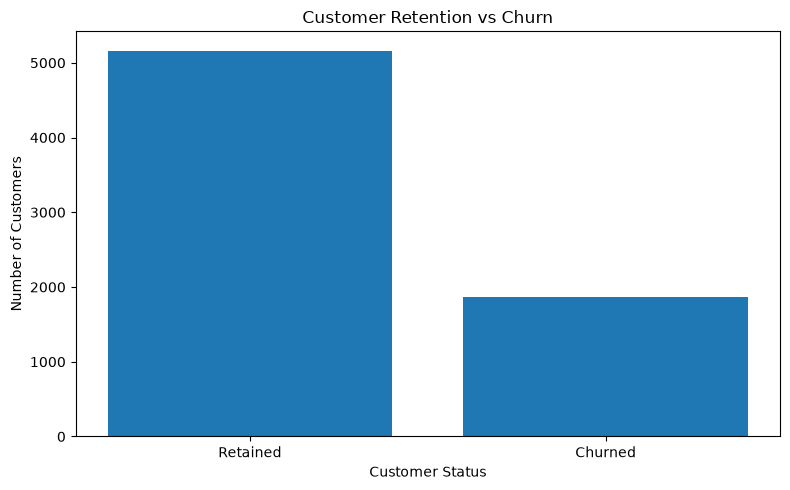

In [7]:
retention_data = pd.DataFrame({
    "Status": ["Retained", "Churned"],
    "Customers": [
        retained_customers,
        churned_customers
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    retention_data["Status"],
    retention_data["Customers"]
)

plt.title("Customer Retention vs Churn")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "day38_retention_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

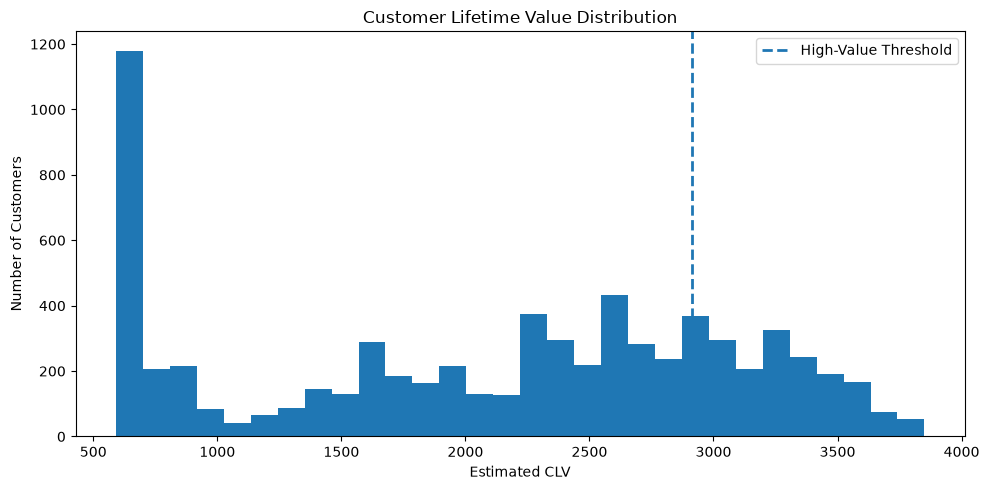

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(
    data["EstimatedCLV"],
    bins=30
)

plt.axvline(
    clv_threshold,
    linestyle="--",
    linewidth=2,
    label="High-Value Threshold"
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Estimated CLV")
plt.ylabel("Number of Customers")
plt.legend()

plt.tight_layout()

plt.savefig(
    "day38_clv_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

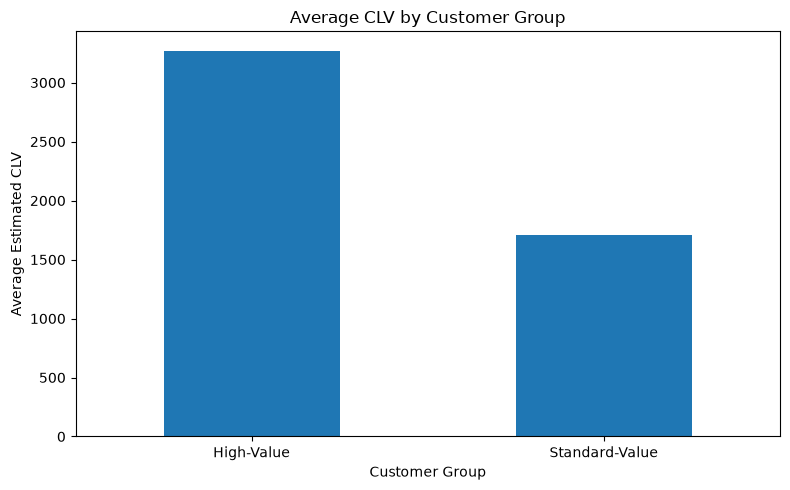

In [10]:
plt.figure(figsize=(8, 5))

clv_summary["AverageCLV"].plot(
    kind="bar"
)

plt.title("Average CLV by Customer Group")
plt.xlabel("Customer Group")
plt.ylabel("Average Estimated CLV")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "day38_clv_group_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
tenure_groups = pd.cut(
    data["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0–12 Months",
        "13–24 Months",
        "25–48 Months",
        "49–72 Months"
    ]
)

retention_by_tenure = (
    data.groupby(tenure_groups, observed=False)["ChurnFlag"]
    .agg(
        CustomerCount="count",
        ChurnRate="mean"
    )
)

retention_by_tenure["RetentionRate"] = (
    1 - retention_by_tenure["ChurnRate"]
) * 100

retention_by_tenure["ChurnRate"] = (
    retention_by_tenure["ChurnRate"] * 100
)

retention_by_tenure = retention_by_tenure.round(2)

display(retention_by_tenure)

,CustomerCount,ChurnRate,RetentionRate
tenure,,,
0–12 Months,2175,47.68,52.32
13–24 Months,1024,28.71,71.29
25–48 Months,1594,20.39,79.61
49–72 Months,2239,9.51,90.49


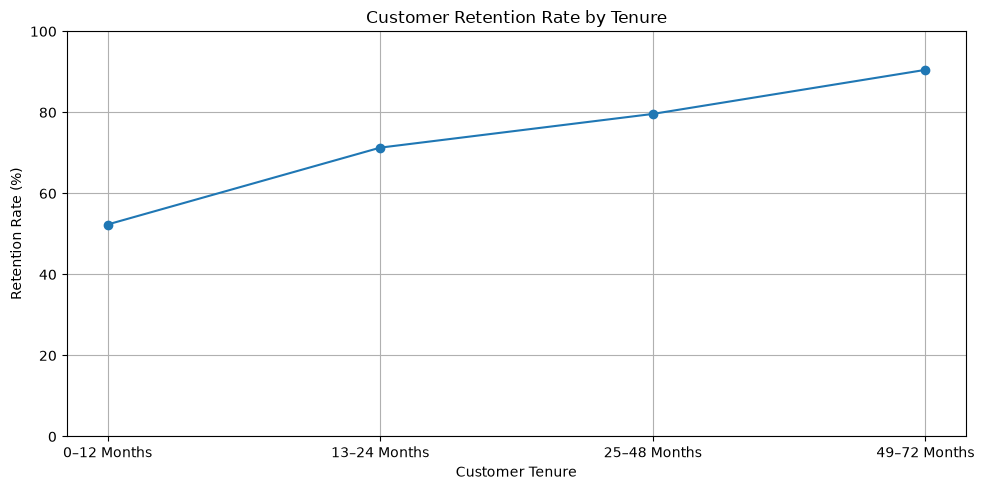

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    retention_by_tenure.index.astype(str),
    retention_by_tenure["RetentionRate"],
    marker="o"
)

plt.title("Customer Retention Rate by Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Retention Rate (%)")
plt.ylim(0, 100)
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "day38_retention_by_tenure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
highest_churn_group = retention_by_tenure["ChurnRate"].idxmax()
highest_retention_group = retention_by_tenure["RetentionRate"].idxmax()

strategies = f"""
DAY 38 — CUSTOMER RETENTION STRATEGIES

1. Early Customer Retention
Focus on customers in the early-tenure groups with onboarding,
support, and personalized engagement.

2. High-Value Customer Retention
High-CLV customers should receive appropriate loyalty programs,
personalized offers, and proactive support.

3. Churn Risk Monitoring
Monitor customers with high charges or shorter tenure because
these characteristics can be useful for identifying groups
that require further retention analysis.

4. Long-Term Loyalty
Customers with longer tenure can be encouraged to remain loyal
through relevant rewards and service improvements.

5. Data-Driven Retention
Use CLV, tenure, churn behavior, and customer characteristics
together rather than relying on a single metric.

Highest observed churn group in this analysis:
{highest_churn_group}

Highest observed retention group in this analysis:
{highest_retention_group}

Important:
These recommendations are analytical suggestions based on the
available dataset. They do not establish that a particular
strategy will cause retention to increase.
"""

print(strategies)

with open(
    "day38_retention_strategy_report.txt",
    "w"
) as file:
    file.write(strategies)


DAY 38 — CUSTOMER RETENTION STRATEGIES

1. Early Customer Retention
Focus on customers in the early-tenure groups with onboarding,
support, and personalized engagement.

2. High-Value Customer Retention
High-CLV customers should receive appropriate loyalty programs,
personalized offers, and proactive support.

3. Churn Risk Monitoring
Monitor customers with high charges or shorter tenure because
these characteristics can be useful for identifying groups
that require further retention analysis.

4. Long-Term Loyalty
Customers with longer tenure can be encouraged to remain loyal
through relevant rewards and service improvements.

5. Data-Driven Retention
Use CLV, tenure, churn behavior, and customer characteristics
together rather than relying on a single metric.

Highest observed churn group in this analysis:
0–12 Months

Highest observed retention group in this analysis:
49–72 Months

Important:
These recommendations are analytical suggestions based on the
available dataset. They do n

In [14]:
# Save CLV customer-level results
data[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn",
        "EstimatedCLV",
        "CLVGroup"
    ]
].to_csv(
    "day38_customer_clv_analysis.csv",
    index=False
)

# Save retention metrics
retention_metrics = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Retained Customers",
        "Churned Customers",
        "Retention Rate",
        "Churn Rate",
        "Average Tenure"
    ],
    "Value": [
        total_customers,
        retained_customers,
        churned_customers,
        retention_rate,
        churn_rate,
        average_tenure
    ]
})

retention_metrics.to_csv(
    "day38_retention_metrics.csv",
    index=False
)

# Save CLV summary
clv_summary.to_csv(
    "day38_clv_summary.csv"
)

# Save retention by tenure
retention_by_tenure.to_csv(
    "day38_retention_by_tenure.csv"
)

print("All Day 38 outputs saved successfully! ✅")

All Day 38 outputs saved successfully! ✅
